# Hexadic Diamond

Use 2D projection of 5D lattice (from 'cut and project' approach to developing a Penrose tiling) to derive the Hexadic Diamond of Erv Wilson.

<a>"https://www.anaphoria.com/diamond.pdf"<a>

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Rational, Integer
from itertools import combinations

from ji_tiling import basis2D, make_int_grid

### Set 5D rotation matrix and find eigenvectors

In [2]:
rotationMatrix = np.array([[0.,1.,0.,0.,0.],[0.,0.,1.,0.,0.],[0.,0.,0.,1.,0.],[0.,0.,0.,0.,1.],[1.,0.,0.,0.,0.]]) 
# rotationMatrix = np.array( [[0,0,0,0,1],[1,0,0,0,0],[0,1,0,0,0],[0,0,1,0,0],[0,0,0,1,0]] ) # Senechal
print(rotationMatrix)

eigenValues, eigenVectors = np.linalg.eig(rotationMatrix)

[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]]


### Projection to 2D plane
Select the eigenvectors that project 5D vector to 2D plane with $\frac{2}{3}\pi$ rotation between axes.

In [3]:
# The projection plane
print('2D projection plane:')
p = basis2D(eigenVectors,2,3)

2D projection plane:
-->5D basis vectors are rotated in 2D plane by (2.0π)/5


In [4]:
# Refactored: range(-1, 2) is equivalent to make_int_grid(d=1)
z5 = make_int_grid(1)
print(f'Integer grid: {z5.shape}')

Integer grid: (243, 5)


### Restrict points such that there is a single interval (or unity) in numerator -- same for denominator

In [5]:
xy_ = []
r_ = []      # raw sympy Rationals (no octave reduction)
pts5_ = []

rI = np.array([3,5,7,9,11])

for pt5 in z5:    
    if (np.sum(pt5<0) < 2) and (np.sum(pt5>0) < 2):
        pS = Rational(rI[0],1)**Integer(pt5[0]) * \
             Rational(rI[1],1)**Integer(pt5[1]) * \
             Rational(rI[2],1)**Integer(pt5[2]) * \
             Rational(rI[3],1)**Integer(pt5[3]) * \
             Rational(rI[4],1)**Integer(pt5[4])

        r_.append(pS)
        xy_.append(p@pt5)
        pts5_.append(pt5.copy())

xy_ = np.asarray(xy_)
pts5_ = np.asarray(pts5_)

### Plot the Hexadic Diamond

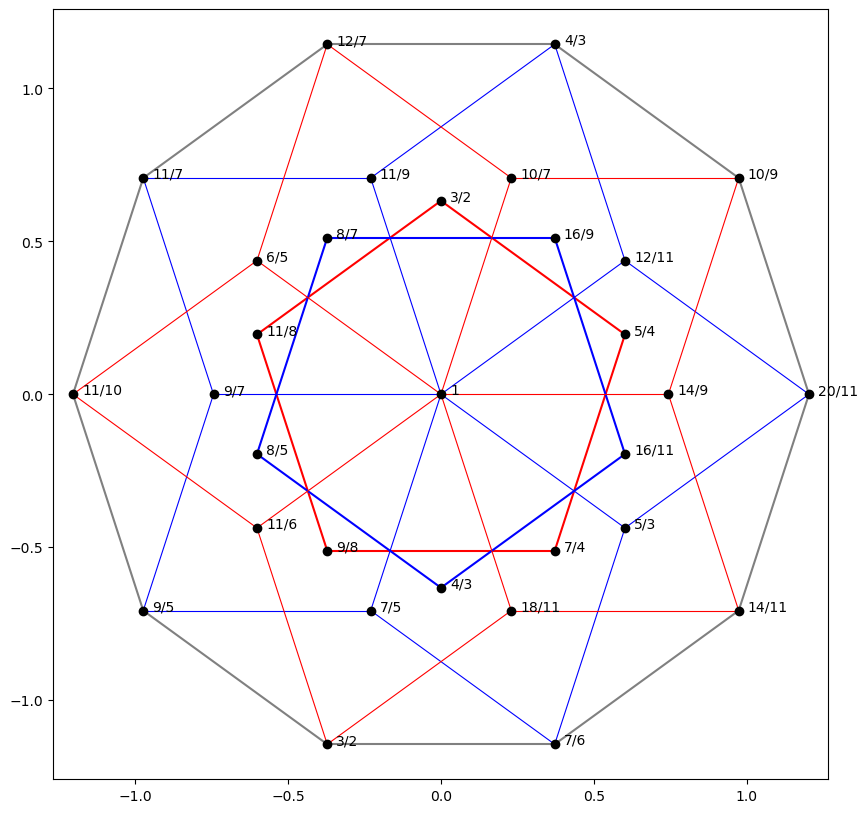

In [6]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

# Rotate 90 degrees to align with Erv Wilson's Hexadic Diamond
x_ = -xy_[:,1]
y_ = xy_[:,0]

def find_idx(pt):
    matches = np.where(np.all(pts5_ == np.array(pt, dtype=float), axis=1))[0]
    return matches[0] if len(matches) else None

def draw_pentagon(ax, indices, color):
    angles = np.arctan2([y_[i] for i in indices], [x_[i] for i in indices])
    indices = [indices[k] for k in np.argsort(angles)]
    for k in range(len(indices)):
        i, j = indices[k], indices[(k+1) % len(indices)]
        ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color=color, linewidth=1.5, zorder=0)

def cyclic(lst, i):
    return lst[-i:] + lst[:-i] if i > 0 else lst[:]

def draw_belt(ax, a, b, color, lw=0.8):
    """Draw V-shaped lines: outer[k] → bridge[k] → outer[k+1]
    a: base outer-belt point, b: base bridge point (cyclic permutations of each)"""
    outer_pts5 = [cyclic(a, i) for i in range(5)]
    inner_pts5 = [cyclic(b, i) for i in range(5)]
    for k in range(5):
        i1 = find_idx(outer_pts5[k])
        i2 = find_idx(outer_pts5[(k+1) % 5])
        im = find_idx(inner_pts5[k])
        if None not in (i1, i2, im):
            ax.plot([x_[i1], x_[im]], [y_[i1], y_[im]], color=color, linewidth=lw, zorder=0)
            ax.plot([x_[im], x_[i2]], [y_[im], y_[i2]], color=color, linewidth=lw, zorder=0)

# Step 1: red pentagon — otonal basis points (single element == +1)
idx_otonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.max() == 1]
draw_pentagon(ax, idx_otonal, 'r')

# Step 2: blue pentagon — utonal basis points (single element == -1)
idx_utonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.min() == -1]
draw_pentagon(ax, idx_utonal, 'b')

# Step 3: blue (thin) lines — utonal star
draw_belt(ax, [-1, 0,  1, 0, 0],
              [ 0,-1,  1, 0, 0], 'b')

# Step 4: red (thin) lines — otonal star
draw_belt(ax, [ 1, 0, -1, 0, 0],
              [ 0, 1, -1, 0, 0], 'r')

# Step 5: grey decagon — connect the 10 outermost points
distances = np.sqrt(x_**2 + y_**2)
idx_outer10 = list(np.argsort(distances)[-10:])
angles = np.arctan2([y_[i] for i in idx_outer10], [x_[i] for i in idx_outer10])
idx_outer10 = [idx_outer10[k] for k in np.argsort(angles)]
for k in range(10):
    i, j = idx_outer10[k], idx_outer10[(k+1) % 10]
    ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color='grey', linewidth=1.5, zorder=0)

# Step 6: radial lines from origin to bridge points, colored by star
orange_bridges = [cyclic([0,  1, -1, 0, 0], i) for i in range(5)]
cyan_bridges   = [cyclic([0, -1,  1, 0, 0], i) for i in range(5)]

for pt in orange_bridges:
    i = find_idx(pt)
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='r', linewidth=0.8, zorder=0)

for pt in cyan_bridges:
    i = find_idx(pt)
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='b', linewidth=0.8, zorder=0)

ax.plot(x_, y_, 'ko', zorder=1)

# Annotate with octave-reduced ratio
for i, pS in enumerate(r_):
    pS_oct = pS
    while pS_oct > 2: pS_oct /= 2
    while pS_oct < 1: pS_oct *= 2
    ax.annotate(str(pS_oct), xy=[x_[i]+0.03, y_[i]], textcoords='data')

# ax.grid()
plt.axis('equal')
plt.savefig('../hexadic_diamond.png')
plt.show()

** Intersection of Hexadic Diamond with Eikosany

Reproduction of Wilson's Figure 15 of D'Allesandro

Eikosany is merged with the Hexadic Diamond by first dividing all notes by 3*5*11.  This is the value of the note with uppermost position in Figure 13.

Then, to get get the orientation aligned with the Hexadic Diamond, it is necessary to
- rotate by $\frac{\pi}{2}$,
- flip sign of the x values such that the Eikosany is mirrored about y axis

Note that the rotation is different than that used for the Hexadic Diamond. Also, axes are not permuted.

In [7]:
# Set up Eikosany
eiko_6 = np.zeros((20,6),dtype=np.int32)

for i,c in enumerate( combinations((0, 1, 2, 3, 4, 5),3) ):
    eiko_6[i,c] =  1

eiko_5 = eiko_6[:,1:]

In [8]:
pE = symbols('pE')

xy_E = []
r_E = []
r_prod = []
rS = ('1','3','5','7','9','11')
rI = np.array([3,5,7,9,11])

for pt5 in eiko_6:

    # Omit the first entry, Integer(pt5[0]), for Eikosany (unity)
    # Divide each combination of 3 integers by (3*5*11)
    pS = Rational(rI[0],1)**Integer(pt5[1]) * \
         Rational(rI[1],1)**Integer(pt5[2]) * \
         Rational(rI[2],1)**Integer(pt5[3]) * \
         Rational(rI[3],1)**Integer(pt5[4]) * \
         Rational(rI[4],1)**Integer(pt5[5]) * \
         Rational(1,3) * Rational(1,5) * Rational(1,11)

    while ( pS>2 ):
        pS = pS/ 2
    while ( pS<1 ):
        pS = pS*2

    r_E.append( str(pS) )

    r_prod.append(pS)

    xy_E.append( p@(pt5[1:] +np.array((-1,-1,0,0,-1))) )

xy_E = np.asarray(xy_E)

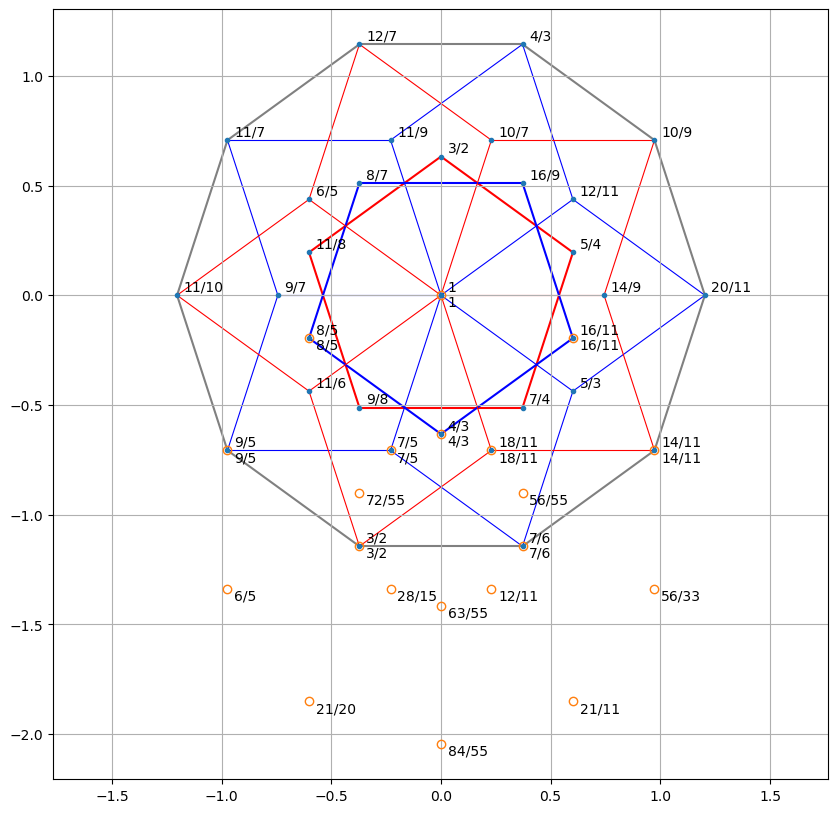

In [9]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

########################################

# Step 1: red pentagon — otonal basis points (single element == +1)
idx_otonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.max() == 1]
draw_pentagon(ax, idx_otonal, 'r')

# Step 2: blue pentagon — utonal basis points (single element == -1)
idx_utonal = [i for i, pt in enumerate(pts5_)
              if np.sum(pt != 0) == 1 and pt.min() == -1]
draw_pentagon(ax, idx_utonal, 'b')

# Step 3: blue (thin) lines — utonal star
draw_belt(ax, [-1, 0,  1, 0, 0],
              [ 0,-1,  1, 0, 0], 'b')

# Step 4: red (thin) lines — otonal star
draw_belt(ax, [ 1, 0, -1, 0, 0],
              [ 0, 1, -1, 0, 0], 'r')

# Step 5: grey decagon — connect the 10 outermost points
distances = np.sqrt(x_**2 + y_**2)
idx_outer10 = list(np.argsort(distances)[-10:])
angles = np.arctan2([y_[i] for i in idx_outer10], [x_[i] for i in idx_outer10])
idx_outer10 = [idx_outer10[k] for k in np.argsort(angles)]
for k in range(10):
    i, j = idx_outer10[k], idx_outer10[(k+1) % 10]
    ax.plot([x_[i], x_[j]], [y_[i], y_[j]], color='grey', linewidth=1.5, zorder=0)

# Step 6: radial lines from origin to bridge points, colored by star
orange_bridges = [cyclic([0,  1, -1, 0, 0], i) for i in range(5)]
cyan_bridges   = [cyclic([0, -1,  1, 0, 0], i) for i in range(5)]

for pt in orange_bridges:
    i = find_idx(pt)
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='r', linewidth=0.8, zorder=0)

for pt in cyan_bridges:
    i = find_idx(pt)
    if i is not None:
        ax.plot([0, x_[i]], [0, y_[i]], color='b', linewidth=0.8, zorder=0)
########################################
x_ = -xy_[:,1]
y_ = xy_[:,0]

xE_ = -xy_E[:,1]
yE_ = xy_E[:,0]

ax.plot(x_,y_,'.')
# Annotate with octave-reduced ratio
for i, pS in enumerate(r_):
    pS_oct = pS
    while pS_oct > 2: pS_oct /= 2
    while pS_oct < 1: pS_oct *= 2
    ax.annotate(str(pS_oct), xy=[x_[i]+0.03, y_[i]+0.02], textcoords='data')

ax.plot(xE_,yE_,'o',markerfacecolor='none')
for i,rl in enumerate(r_prod):                                       # <--
    ax.annotate(str(rl), xy=[xE_[i]+0.03,yE_[i]-0.05], textcoords='data') # <--

ax.grid()
plt.axis('equal')
# plt.savefig('hexadic_diamond.png')
plt.show()